In [1]:
%pip install python-docx langchain

Note: you may need to restart the kernel to use updated packages.


In [34]:
from docx import Document as DocxDocument
from langchain_core.documents import Document
import re

def load_docx(file_path):
    doc = DocxDocument(file_path)
    full_text = []

    for para in doc.paragraphs:
        text = para.text.strip()
        if text:
            full_text.append(text)

    return "\n".join(full_text)


def split_law_articles(text):
    # 줄 단위 기준으로 조문 찾기
    pattern = r"(?m)^(제\d+조(?:의\d+)?(?:\s*\(.*?\))?)"

    parts = re.split(pattern, text)

    docs = []

    for i in range(1, len(parts), 2):
        article_title = parts[i].strip()
        content = parts[i + 1].strip() if i + 1 < len(parts) else ""

        full_text = f"{article_title} {content}"

        # 너무 짧은 건 제거
        if len(full_text) < 20:
            continue

        docs.append(
            Document(
                page_content=full_text,
                metadata={
                    "article": article_title
                }
            )
        )

    return docs




In [ ]:
file_path = "./documents/income_tax.docx"

text = load_docx(file_path)
document_list = split_law_articles(text)


print(f"총 {len(document_list)}개 조문 생성")

# print("\n샘플:")
# print(docs[0]["content"][:500])
# print(docs[0]["metadata"])
# docs[69]

for i, doc in enumerate(document_list):
    print(f"\n===== [{i}] =====")
    print(doc.page_content)
    print(doc.metadata)

# print(docs)

In [6]:
%pip install -q langchain-chroma

Note: you may need to restart the kernel to use updated packages.


In [11]:
from langchain_openai import OpenAIEmbeddings

embeddings = OpenAIEmbeddings(model="text-embedding-3-large")



In [36]:
from langchain_chroma import Chroma

vector_store = Chroma.from_documents(
    documents=document_list,
    embedding=embeddings,
    collection_name="income_tax_collection",
    persist_directory="./income_tax_collection"
)


In [39]:
retriever = vector_store.as_retriever(search_kwargs={"k": 3})

In [37]:
query = "연봉 5천만원 직장인의 소득세는?"

In [46]:
retriever.invoke(query)
# print(out[1])

[Document(id='83502ad6-fd8e-4c74-8433-e1f11fcc5a2a', metadata={'article': '제55조(세율)'}, page_content='제55조(세율) ①거주자의 종합소득에 대한 소득세는 해당 연도의 종합소득과세표준에 다음의 세율을 적용하여 계산한 금액(이하 “종합소득산출세액”이라 한다)을 그 세액으로 한다. <개정 2014. 1. 1., 2016. 12. 20., 2017. 12. 19., 2020. 12. 29., 2022. 12. 31.>\n| 구분 | 종합소득 과세표준 구간 | 세율 |\n|------|----------------------|------|\n| 1 | 1,400만원 이하 | 과세표준의 6% |\n| 2 | 1,400만원 초과 ~ 5,000만원 이하 | 84만원 + [(1,400만원 초과 금액) × 15%] |\n| 3 | 5,000만원 초과 ~ 8,800만원 이하 | 624만원 + [(5,000만원 초과 금액) × 24%] |\n| 4 | 8,800만원 초과 ~ 1억5천만원 이하 | 1,536만원 + [(8,800만원 초과 금액) × 35%] |\n| 5 | 1억5천만원 초과 ~ 3억원 이하 | 3,706만원 + [(1억5천만원 초과 금액) × 38%] |\n| 6 | 3억원 초과 ~ 5억원 이하 | 9,406만원 + [(3억원 초과 금액) × 40%] |\n| 7 | 5억원 초과 ~ 10억원 이하 | 1억 7,406만원 + [(5억원 초과 금액) × 42%] |\n| 8 | 10억원 초과 | 3억 8,406만원 + [(10억원 초과 금액) × 45%] |\n② 거주자의 퇴직소득에 대한 소득세는 다음 각 호의 순서에 따라 계산한 금액(이하 “퇴직소득 산출세액”이라 한다)으로 한다.<개정 2013. 1. 1., 2014. 12. 23.>\n1. 해당 과세기간의 퇴직소득과세표준에 제1항의 세율을 적용하여 계산한 금액\n2. 제1호의 금액을 12로 나눈 금액에 근속연수를 곱한 금액\n3. 삭제<2

In [47]:
from typing_extensions import TypedDict

class AgentState(TypedDict):
    query: str
    context: list[Document]
    answer: str
    

In [62]:
from langgraph.graph import StateGraph

graph_builder = StateGraph(AgentState)


In [63]:
def retrieve(state: AgentState):
    query = state["query"]
    docs = retriever.invoke(state["query"])
    return {"context": docs}


In [64]:
# Create a LangSmith API in Settings > API Keys
# Make sure API key env var is set:
# import os; os.environ["LANGSMITH_API_KEY"] = "<your-api-key>"
from langsmith import Client
from langchain_openai import ChatOpenAI

client = Client()
prompt = client.pull_prompt("rlm/rag-prompt")

llm = ChatOpenAI(model='gpt-4o')

In [65]:
def generate(state: AgentState):
    context = state['context']
    query = state['query']
    rag_chain = prompt | llm
    response = rag_chain.invoke({'question': query,'context': context})
    return {'answer': response}

In [66]:
graph_builder.add_node('retrieve', retrieve)
graph_builder.add_node('generate', generate)

In [67]:
from langgraph.graph import START, END

graph_builder.add_edge(START, 'retrieve')
graph_builder.add_edge('retrieve', 'generate')
graph_builder.add_edge('generate', END)

In [68]:
graph = graph_builder.compile()

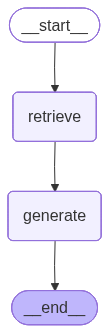

In [71]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [72]:
initial_state = {'query': query}
graph.invoke(initial_state)

{'query': '연봉 5천만원 직장인의 소득세는?',
 'context': [Document(id='83502ad6-fd8e-4c74-8433-e1f11fcc5a2a', metadata={'article': '제55조(세율)'}, page_content='제55조(세율) ①거주자의 종합소득에 대한 소득세는 해당 연도의 종합소득과세표준에 다음의 세율을 적용하여 계산한 금액(이하 “종합소득산출세액”이라 한다)을 그 세액으로 한다. <개정 2014. 1. 1., 2016. 12. 20., 2017. 12. 19., 2020. 12. 29., 2022. 12. 31.>\n| 구분 | 종합소득 과세표준 구간 | 세율 |\n|------|----------------------|------|\n| 1 | 1,400만원 이하 | 과세표준의 6% |\n| 2 | 1,400만원 초과 ~ 5,000만원 이하 | 84만원 + [(1,400만원 초과 금액) × 15%] |\n| 3 | 5,000만원 초과 ~ 8,800만원 이하 | 624만원 + [(5,000만원 초과 금액) × 24%] |\n| 4 | 8,800만원 초과 ~ 1억5천만원 이하 | 1,536만원 + [(8,800만원 초과 금액) × 35%] |\n| 5 | 1억5천만원 초과 ~ 3억원 이하 | 3,706만원 + [(1억5천만원 초과 금액) × 38%] |\n| 6 | 3억원 초과 ~ 5억원 이하 | 9,406만원 + [(3억원 초과 금액) × 40%] |\n| 7 | 5억원 초과 ~ 10억원 이하 | 1억 7,406만원 + [(5억원 초과 금액) × 42%] |\n| 8 | 10억원 초과 | 3억 8,406만원 + [(10억원 초과 금액) × 45%] |\n② 거주자의 퇴직소득에 대한 소득세는 다음 각 호의 순서에 따라 계산한 금액(이하 “퇴직소득 산출세액”이라 한다)으로 한다.<개정 2013. 1. 1., 2014. 12. 23.>\n1. 해당 과세기간의 퇴직소득과세표준에 제1항의 세율을 적용하여 계산한 금액\